# Pick fixed spawn/goal routes for the trajectory-comparison eval

One cell per candidate map: set `SPAWN`/`GOAL` (world coordinates - read them off the plotted
preview's own axes), re-run the cell, see the route redrawn immediately. Pre-filled with an
auto-picked (BFS-verified, farthest-reachable-point) starting route on each map, so every cell
already shows something valid - tweak from there rather than starting blank.

Once you've settled on your final 10 (delete/skip the rest, or leave extras in - only
`FINAL_MAP_ORDER` in the last cell decides what actually goes into `candidates.json`), run the
last cell to bake everything into `hpc/0816/trajectories/candidates.json`, ready for
`eval_trajectories.py run`.

**Run this notebook from the repo root** (same directory as `eval_trajectories.py`) so the plain
relative paths below resolve correctly.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

from eval_trajectories import (
    load_map_grid, build_candidate_from_points, plot_candidate,
    asphalt_components, pick_candidate, cell_to_world,
)
import numpy as np

# MAPS_DIR is where cells below actually read grid content from for the interactive preview loop -
# the shortlist copy is fine for this (same content as the real folder). FULL_MAPS_DIR is the
# folder Unity actually loads from at runtime - map_index in the final candidates.json MUST be
# computed from THIS folder's sorted listing, not the shortlist's (see the last cell).
MAPS_DIR = Path("hpc/0816/trajectories/map_shortlist")
FULL_MAPS_DIR = Path("Assets/Resources/Maps/VoronoiVal")
GRIDSIZE, CELLSIZE = 66, 1.5

candidates_by_map = {}  # map_file -> candidate dict, updated in place each time you re-run a cell


def make_candidate(map_file, spawn, goal):
    return build_candidate_from_points(
        MAPS_DIR / map_file, 0, spawn[0], spawn[1], goal[0], goal[1], GRIDSIZE, CELLSIZE)


def show_candidate(candidate, map_file):
    if candidate is None:
        print(f"{map_file}: no valid candidate - see the error above (unreachable, or no road "
              f"within 6 cells of one of the points). Try different coordinates.")
        return
    grid = load_map_grid(MAPS_DIR / map_file)
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_candidate(ax, grid, GRIDSIZE, CELLSIZE, candidate)
    plt.show()
    pl, hd = candidate["path_len_cells"], candidate["heading_deg"]
    sc = (candidate["x_spawn_cell"], candidate["z_spawn_cell"])
    gc = (candidate["x_goal_cell"], candidate["z_goal_cell"])
    print(f"path length: {pl} cells   heading: {hd:.1f} deg   spawn cell: {sc}   goal cell: {gc}")


def auto_start(map_file, seed):
    """Only used to pre-fill a reasonable starting SPAWN/GOAL below - same farthest-reachable-
    point BFS approach as eval_trajectories.py generate. Purely a convenience default; feel free
    to overwrite SPAWN/GOAL with anything you prefer."""
    grid = load_map_grid(MAPS_DIR / map_file)
    comp = asphalt_components(grid)
    rng = np.random.default_rng(seed)
    result = pick_candidate(grid, comp, rng, min_path_cells=15)
    if result is None:
        return (0.0, 0.0), (0.0, 0.0)
    spawn = cell_to_world(result["x_spawn_cell"], result["z_spawn_cell"], GRIDSIZE, CELLSIZE)
    goal = cell_to_world(result["x_goal_cell"], result["z_goal_cell"], GRIDSIZE, CELLSIZE)
    return spawn, goal


### curved_401.txt

In [2]:
MAP_FILE = "curved_401.txt"
SPAWN, GOAL = (45, 7), (-45, 42)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


auto-picked SPAWN=(45, 7) GOAL=(-45, 42) - edit above and re-run to try your own


FileNotFoundError: [Errno 2] No such file or directory: 'hpc\\0816\\trajectories\\map_shortlist\\curved_401.txt'

### curved_406.txt

auto-picked SPAWN=(5, 45) GOAL=(45, -45) - edit above and re-run to try your own


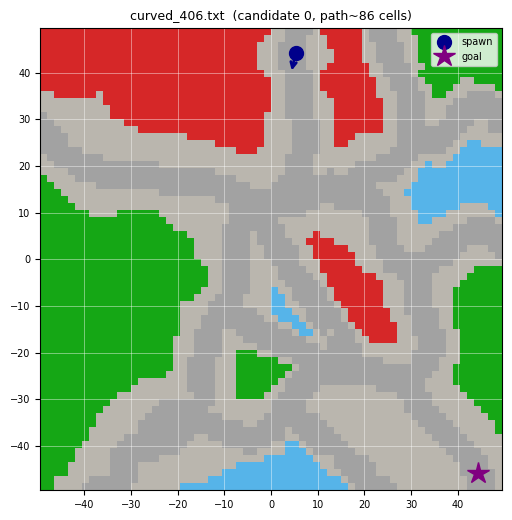

path length: 86 cells   heading: 192.2 deg   spawn cell: (36, 62)   goal cell: (62, 2)


In [3]:
MAP_FILE = "curved_406.txt"
SPAWN, GOAL = (5, 45), (45, -45)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_407.txt

[traj] curved_407.txt: spawn snapped from cell (49, 2) to road-centered cell (51, 3).


[traj] curved_407.txt: goal snapped from cell (9, 62) to road-centered cell (14, 65).


auto-picked SPAWN=(25, -45) GOAL=(-35, 45) - edit above and re-run to try your own


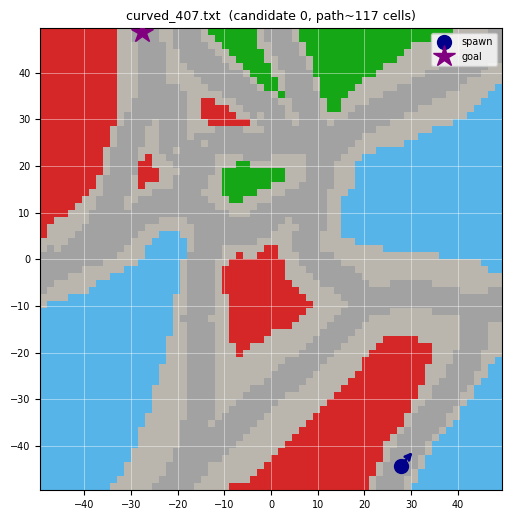

path length: 117 cells   heading: 41.1 deg   spawn cell: (51, 3)   goal cell: (14, 65)


In [4]:
MAP_FILE = "curved_407.txt"
SPAWN, GOAL = (25, -45), (-35, 45)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_438.txt

[traj] curved_438.txt: spawn snapped from cell (2, 7) to road-centered cell (2, 8).


[traj] curved_438.txt: goal snapped from cell (54, 62) to road-centered cell (53, 64).


auto-picked SPAWN=(-45, -38) GOAL=(32, 45) - edit above and re-run to try your own


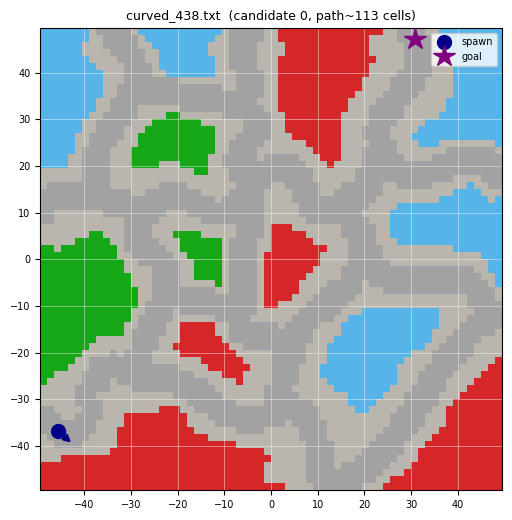

path length: 113 cells   heading: 131.1 deg   spawn cell: (2, 8)   goal cell: (53, 64)


In [5]:
MAP_FILE = "curved_438.txt"
SPAWN, GOAL = (-45, -38), (32, 45)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_442.txt

[traj] curved_442.txt: spawn snapped from cell (59, 2) to road-centered cell (59, 1).


auto-picked SPAWN=(40, -45) GOAL=(-45, 30) - edit above and re-run to try your own


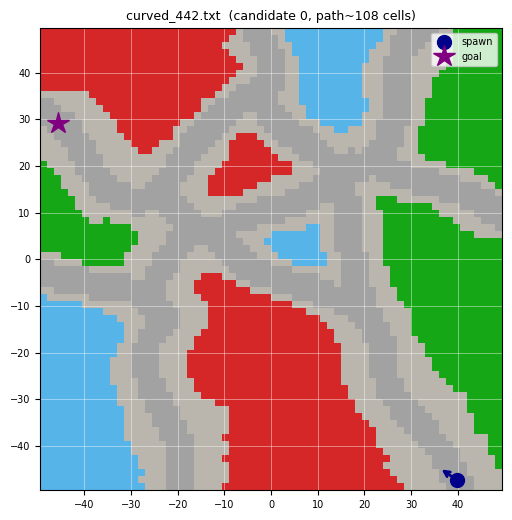

path length: 108 cells   heading: 304.5 deg   spawn cell: (59, 1)   goal cell: (2, 52)


In [6]:
MAP_FILE = "curved_442.txt"
SPAWN, GOAL = (40, -45), (-45, 30)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_444.txt

[traj] curved_444.txt: goal snapped from cell (34, 62) to road-centered cell (32, 64).


auto-picked SPAWN=(15, -30) GOAL=(2, 45) - edit above and re-run to try your own


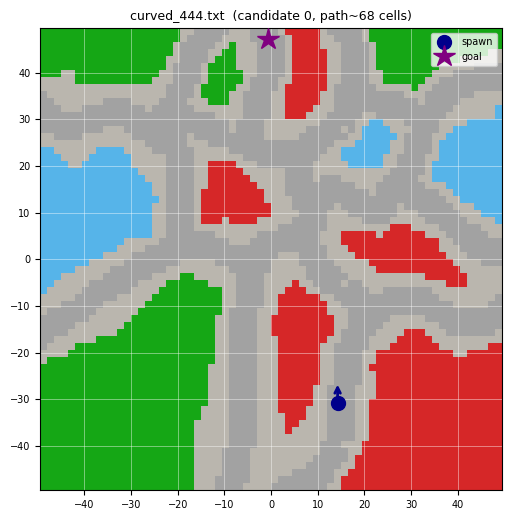

path length: 68 cells   heading: 0.0 deg   spawn cell: (42, 12)   goal cell: (32, 64)


In [7]:
MAP_FILE = "curved_444.txt"
SPAWN, GOAL = (15, -30), (2, 45)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_451.txt

[traj] curved_451.txt: spawn snapped from cell (2, 8) to road-centered cell (2, 14).


[traj] curved_451.txt: goal snapped from cell (62, 50) to road-centered cell (65, 53).


auto-picked SPAWN=(-45, -37) GOAL=(45, 27) - edit above and re-run to try your own


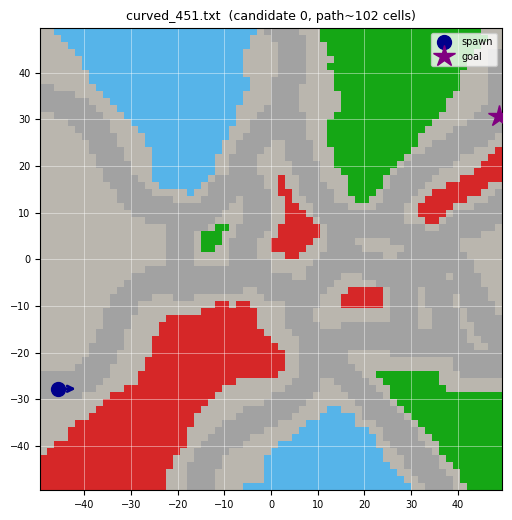

path length: 102 cells   heading: 90.0 deg   spawn cell: (2, 14)   goal cell: (65, 53)


In [8]:
MAP_FILE = "curved_451.txt"
SPAWN, GOAL = (-45, -37), (45, 27)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_480.txt

[traj] curved_480.txt: spawn snapped from cell (2, 2) to road-centered cell (7, 6).


[traj] curved_480.txt: goal snapped from cell (42, 59) to road-centered cell (43, 55).


auto-picked SPAWN=(-45, -45) GOAL=(15, 40) - edit above and re-run to try your own


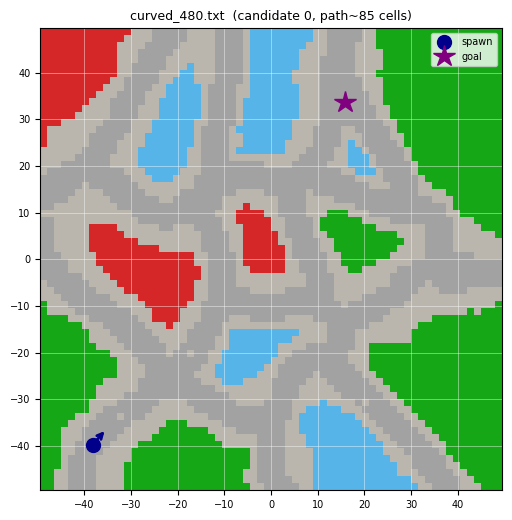

path length: 85 cells   heading: 41.1 deg   spawn cell: (7, 6)   goal cell: (43, 55)


In [9]:
MAP_FILE = "curved_480.txt"
SPAWN, GOAL = (-45, -45), (15, 40)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_484.txt

[traj] curved_484.txt: spawn snapped from cell (2, 42) to road-centered cell (0, 43).


[traj] curved_484.txt: goal snapped from cell (44, 36) to road-centered cell (45, 36).


auto-picked SPAWN=(-45, 15) GOAL=(17, 5) - edit above and re-run to try your own


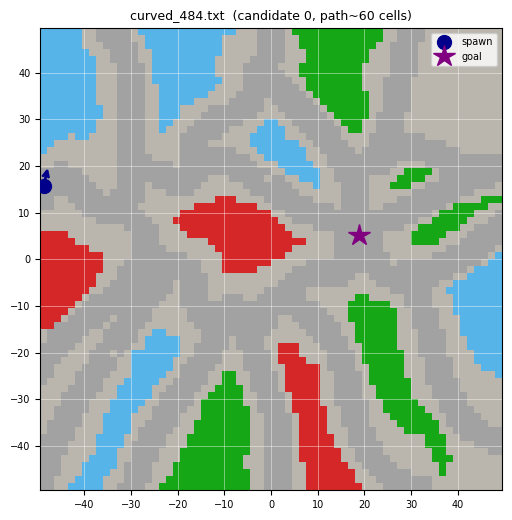

path length: 60 cells   heading: 13.3 deg   spawn cell: (0, 43)   goal cell: (45, 36)


In [10]:
MAP_FILE = "curved_484.txt"
SPAWN, GOAL = (-45, 15), (17, 5)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


### curved_494.txt

[traj] curved_494.txt: spawn snapped from cell (62, 39) to road-centered cell (58, 38).


[traj] curved_494.txt: goal snapped from cell (2, 49) to road-centered cell (0, 49).


auto-picked SPAWN=(45, 10) GOAL=(-45, 25) - edit above and re-run to try your own


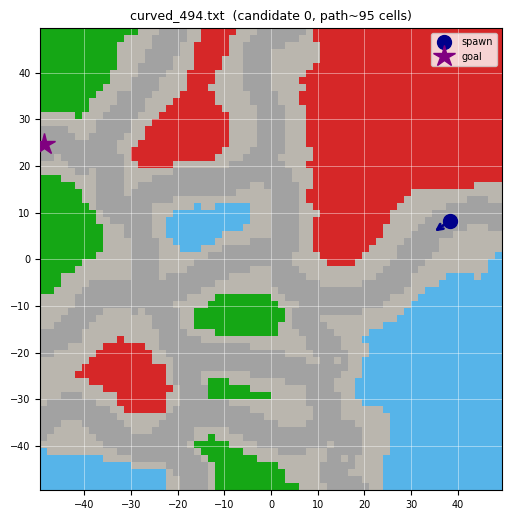

path length: 95 cells   heading: 234.2 deg   spawn cell: (58, 38)   goal cell: (0, 49)


In [11]:
MAP_FILE = "curved_494.txt"
SPAWN, GOAL = (45, 10), (-45, 25)  # delete this line and hardcode your own (x, z) tuples to override
print(f"auto-picked SPAWN={SPAWN} GOAL={GOAL} - edit above and re-run to try your own")

candidate = make_candidate(MAP_FILE, SPAWN, GOAL)
candidates_by_map[MAP_FILE] = candidate
show_candidate(candidate, MAP_FILE)


## Bake the final 10 into candidates.json

Pre-filled with your final 10 (per `map_shortlist_preview/`), in this order - reorder/trim if you
want, only what's listed here gets written out. Each entry is pulled from whatever
`candidates_by_map` currently holds for that map (i.e. whatever the corresponding cell above last
showed you - **run every cell above with your actual chosen routes before running this one**), and
`map_index` is (re)computed from `FULL_MAPS_DIR`'s sorted listing - the value that actually matters
at Unity-runtime, not the shortlist folder's.

In [12]:
FINAL_MAP_ORDER = [
    "curved_401.txt",
    "curved_406.txt",
    "curved_407.txt",
    "curved_438.txt",
    "curved_442.txt",
    "curved_444.txt",
    "curved_451.txt",
    "curved_480.txt",
    "curved_484.txt",
    "curved_494.txt"
]

full_map_files_sorted = sorted(FULL_MAPS_DIR.glob("*.txt"))
index_by_name = {f.name: i for i, f in enumerate(full_map_files_sorted)}

final_candidates = []
for candidate_id, map_file in enumerate(FINAL_MAP_ORDER):
    candidate = candidates_by_map.get(map_file)
    if candidate is None:
        print(f"WARNING: {map_file} has no candidate yet - run its cell above first. Skipping.")
        continue
    if map_file not in index_by_name:
        print(f"WARNING: {map_file} not found in {FULL_MAPS_DIR} - skipping.")
        continue
    c = dict(candidate)
    c["candidate_id"] = candidate_id
    c["map_index"] = index_by_name[map_file]
    final_candidates.append(c)

out_path = Path("hpc/0816/trajectories/candidates.json")
out_path.write_text(json.dumps(final_candidates, indent=2))
print(f"Wrote {len(final_candidates)}/{len(FINAL_MAP_ORDER)} candidates -> {out_path}")


Wrote 10/10 candidates -> hpc\0816\trajectories\candidates.json
